In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols


# EDA

In [2]:
df = pd.read_csv('SuperStoreOrders.csv', encoding='ISO-8859-1')
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31-12-2014,04-01-2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,05-01-2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,02-01-2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,06-01-2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [3]:
df['sales'] = df['sales'].str.replace(',', '') 
df['sales'] = df['sales'].astype(int)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  int64  
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [ ]:
df.col

In [5]:
#drop kolom tidak penting
df.drop(columns=['order_id', 'customer_name', 'product_id', 'product_name'], inplace=True)
df

,order_date,ship_date,ship_mode,segment,state,country,market,region,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,01-01-2011,06-01-2011,Standard Class,Consumer,Constantine,Algeria,Africa,Africa,Office Supplies,Storage,408,2,0.0,106.1400,35.46,Medium,2011
1,01-01-2011,08-01-2011,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Office Supplies,Supplies,120,3,0.1,36.0360,9.72,Medium,2011
2,01-01-2011,05-01-2011,Second Class,Consumer,Budapest,Hungary,EMEA,EMEA,Office Supplies,Storage,66,4,0.0,29.6400,8.17,High,2011
3,01-01-2011,05-01-2011,Second Class,Home Office,Stockholm,Sweden,EU,North,Office Supplies,Paper,45,3,0.5,-26.0550,4.82,High,2011
4,01-01-2011,08-01-2011,Standard Class,Consumer,New South Wales,Australia,APAC,Oceania,Furniture,Furnishings,114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,31-12-2014,04-01-2015,Standard Class,Corporate,California,United States,US,West,Office Supplies,Binders,14,2,0.2,4.5188,0.89,Medium,2014
51286,31-12-2014,05-01-2015,Standard Class,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,Office Supplies,Binders,4,1,0.0,0.4200,0.49,Medium,2014
51287,31-12-2014,02-01-2015,Second Class,Consumer,Managua,Nicaragua,LATAM,Central,Office Supplies,Labels,26,3,0.0,12.3600,0.35,Medium,2014
51288,31-12-2014,06-01-2015,Standard Class,Consumer,Chihuahua,Mexico,LATAM,North,Office Supplies,Labels,7,1,0.0,0.5600,0.20,Medium,2014


In [6]:
len(df.state.unique())

1094

In [185]:
df_all = df[['state','ship_mode', 'segment', 'country', 'market', 'region', 'category', 'sub_category', 'order_priority','quantity','discount','shipping_cost','sales','profit']]
df_all

,state,ship_mode,segment,country,market,region,category,sub_category,order_priority,quantity,discount,shipping_cost,sales,profit
0,Constantine,Standard Class,Consumer,Algeria,Africa,Africa,Office Supplies,Storage,Medium,2,0.000000e+00,3.546000e+01,408,1.061400e+02
1,New South Wales,Standard Class,Consumer,Australia,APAC,Oceania,Office Supplies,Supplies,Medium,3,1.000000e-01,9.720000e+00,120,3.603600e+01
2,Budapest,Second Class,Consumer,Hungary,EMEA,EMEA,Office Supplies,Storage,High,4,0.000000e+00,8.170000e+00,66,2.964000e+01
3,Stockholm,Second Class,Home Office,Sweden,EU,North,Office Supplies,Paper,High,3,5.000000e-01,4.820000e+00,45,-2.605500e+01
4,New South Wales,Standard Class,Consumer,Australia,APAC,Oceania,Furniture,Furnishings,Medium,5,1.000000e-01,4.700000e+00,114,3.777000e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,California,Standard Class,Corporate,United States,US,West,Office Supplies,Binders,Medium,2,2.000000e-01,8.900000e-01,14,4.518800e+00
51286,Souss-Massa-Draâ,Standard Class,Consumer,Morocco,Africa,Africa,Office Supplies,Binders,Medium,1,0.000000e+00,4.900000e-01,4,4.200000e-01
51287,Managua,Second Class,Consumer,Nicaragua,LATAM,Central,Office Supplies,Labels,Medium,3,0.000000e+00,3.500000e-01,26,1.236000e+01
51288,Chihuahua,Standard Class,Consumer,Mexico,LATAM,North,Office Supplies,Labels,Medium,1,0.000000e+00,2.000000e-01,7,5.600000e-01


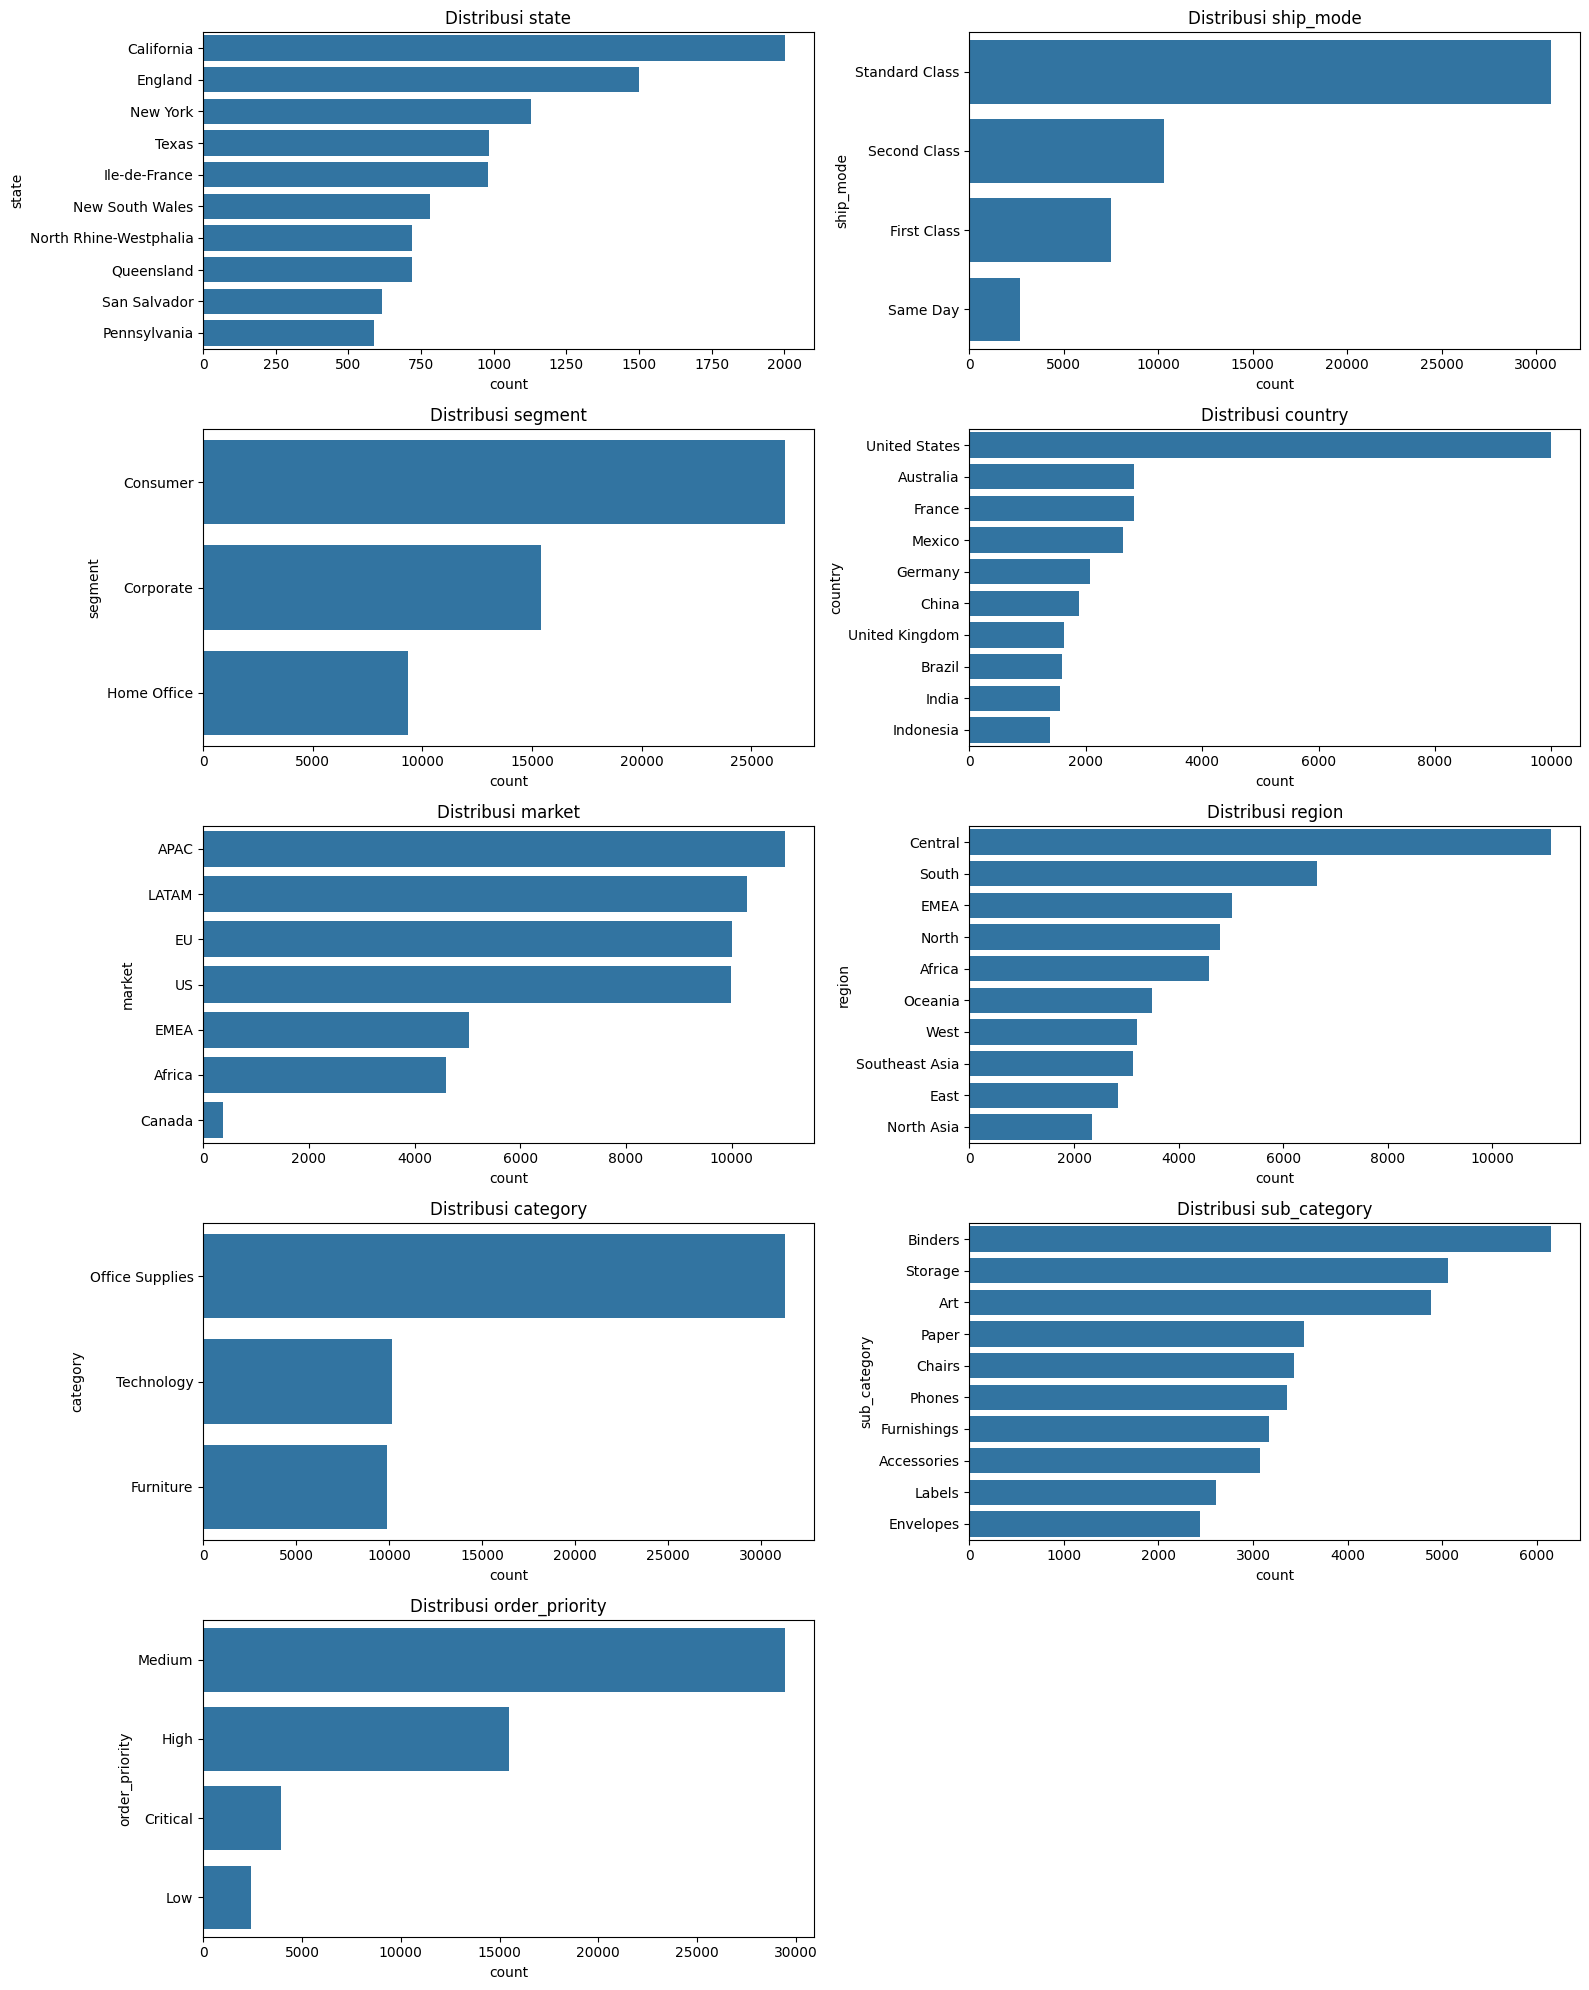

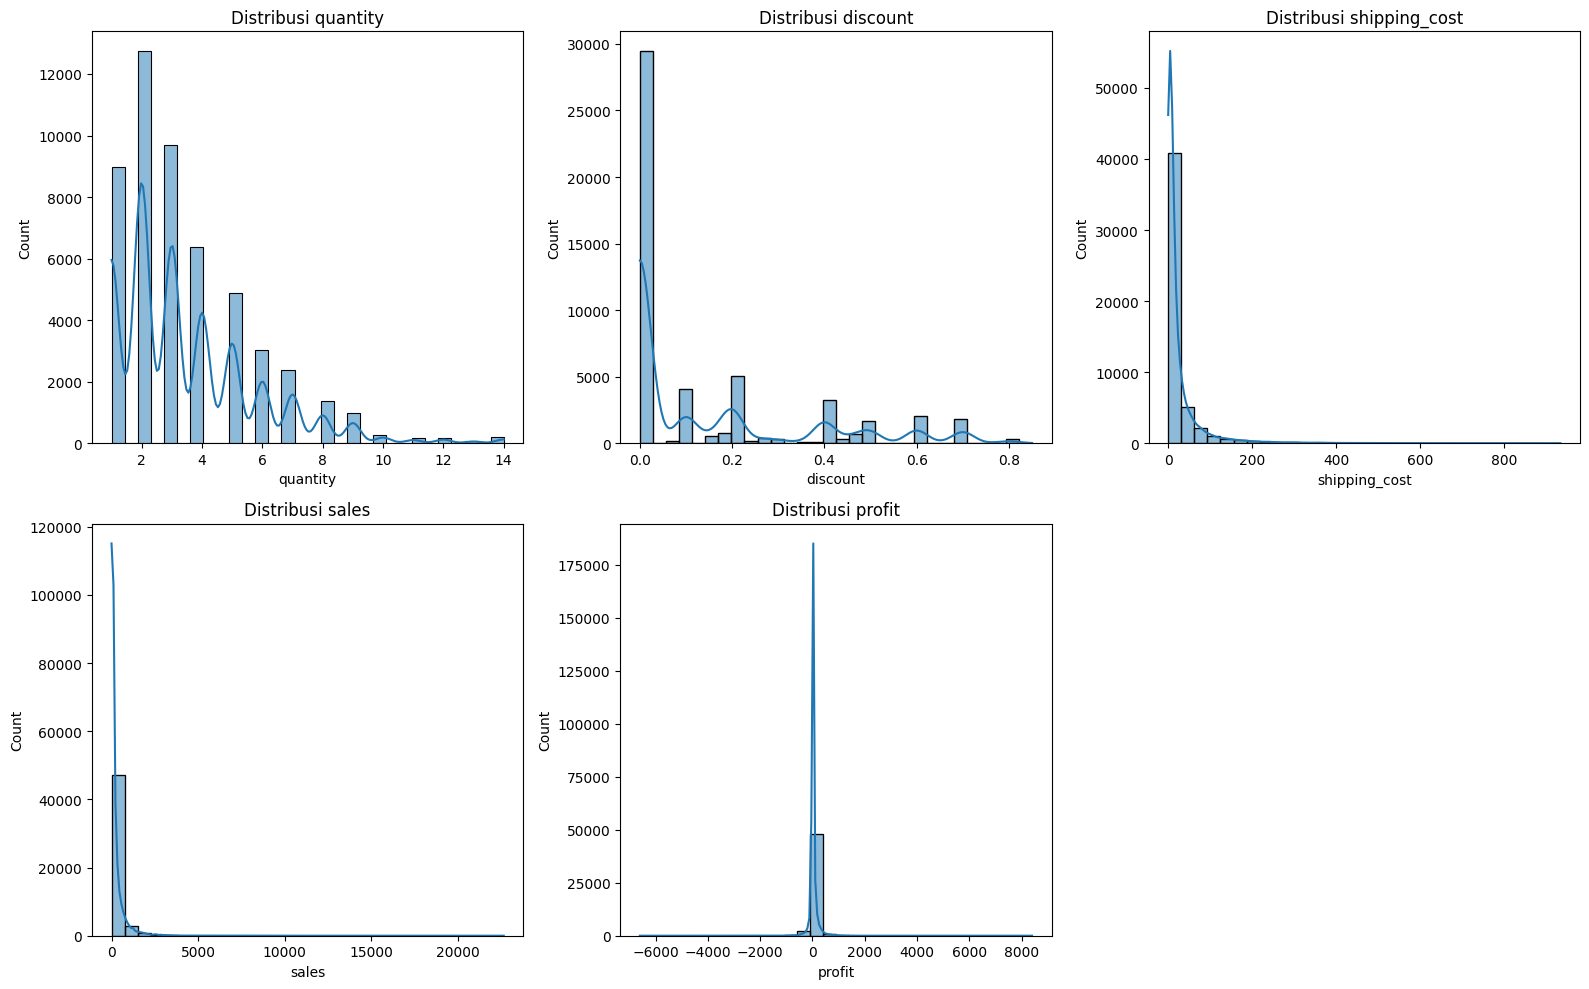

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kategorikal features
categorical_cols = ['state','ship_mode', 'segment', 'country', 'market', 'region', 'category', 'sub_category', 'order_priority']

# Numerikal features
numeric_cols = ['quantity','discount','shipping_cost','sales','profit']

# Plot kategori
plt.figure(figsize=(16, 20))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(5, 2, i)
    sns.countplot(data=df_all, y=col, order=df_all[col].value_counts().index[:10])  # ambil top 10 kategori
    plt.title(f'Distribusi {col}')
    plt.tight_layout()

plt.show()

# Plot numerik
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_all[col], kde=True, bins=30)
    plt.title(f'Distribusi {col}')
    plt.tight_layout()

plt.show()


# TAEGET SHIPPING COST

In [237]:
# drop kolom non target dan non kategorik
df_ship = df[['state','ship_mode', 'segment', 'country', 'market', 'region', 'category', 'sub_category', 'order_priority','shipping_cost']]
df_ship

,state,ship_mode,segment,country,market,region,category,sub_category,order_priority,shipping_cost
0,Constantine,Standard Class,Consumer,Algeria,Africa,Africa,Office Supplies,Storage,Medium,3.546000e+01
1,New South Wales,Standard Class,Consumer,Australia,APAC,Oceania,Office Supplies,Supplies,Medium,9.720000e+00
2,Budapest,Second Class,Consumer,Hungary,EMEA,EMEA,Office Supplies,Storage,High,8.170000e+00
3,Stockholm,Second Class,Home Office,Sweden,EU,North,Office Supplies,Paper,High,4.820000e+00
4,New South Wales,Standard Class,Consumer,Australia,APAC,Oceania,Furniture,Furnishings,Medium,4.700000e+00
...,...,...,...,...,...,...,...,...,...,...
51285,California,Standard Class,Corporate,United States,US,West,Office Supplies,Binders,Medium,8.900000e-01
51286,Souss-Massa-Draâ,Standard Class,Consumer,Morocco,Africa,Africa,Office Supplies,Binders,Medium,4.900000e-01
51287,Managua,Second Class,Consumer,Nicaragua,LATAM,Central,Office Supplies,Labels,Medium,3.500000e-01
51288,Chihuahua,Standard Class,Consumer,Mexico,LATAM,North,Office Supplies,Labels,Medium,2.000000e-01


In [102]:
for col in df_ship.columns:
    if df_ship[col].dtype == 'object' or df_ship[col].dtype.name == 'category':
        model_1way = ols(f'shipping_cost ~ C({col})', data=df_ship).fit()
        anova_1way = sm.stats.anova_lm(model_1way, typ=2)
        pd.options.display.float_format = '{:.6e}'.format
        print(f"{col} One-Way ANOVA:\n", anova_1way)
        print("")

state One-Way ANOVA:
                sum_sq           df            F       PR(>F)
C(state) 6.960858e+06 1.093000e+03 1.980443e+00 1.350908e-70
Residual 1.614170e+08 5.019600e+04          NaN          NaN

ship_mode One-Way ANOVA:
                    sum_sq           df            F        PR(>F)
C(ship_mode) 3.792517e+06 3.000000e+00 3.939253e+02 5.324038e-253
Residual     1.645854e+08 5.128600e+04          NaN           NaN

segment One-Way ANOVA:
                  sum_sq           df            F       PR(>F)
C(segment) 1.180493e+03 2.000000e+00 1.797872e-01 8.354485e-01
Residual   1.683767e+08 5.128700e+04          NaN          NaN

country One-Way ANOVA:
                  sum_sq           df            F        PR(>F)
C(country) 3.620772e+06 1.460000e+02 7.698221e+00 1.582053e-148
Residual   1.647571e+08 5.114300e+04          NaN           NaN

market One-Way ANOVA:
                 sum_sq           df            F        PR(>F)
C(market) 1.907914e+06 6.000000e+00 9.795918e+01 5.3

In [238]:
df_sel = df_ship[[ 'state','country','ship_mode','order_priority', 'market', 'region', 'category', 'sub_category','shipping_cost']]
df_sel

,state,country,ship_mode,order_priority,market,region,category,sub_category,shipping_cost
0,Constantine,Algeria,Standard Class,Medium,Africa,Africa,Office Supplies,Storage,3.546000e+01
1,New South Wales,Australia,Standard Class,Medium,APAC,Oceania,Office Supplies,Supplies,9.720000e+00
2,Budapest,Hungary,Second Class,High,EMEA,EMEA,Office Supplies,Storage,8.170000e+00
3,Stockholm,Sweden,Second Class,High,EU,North,Office Supplies,Paper,4.820000e+00
4,New South Wales,Australia,Standard Class,Medium,APAC,Oceania,Furniture,Furnishings,4.700000e+00
...,...,...,...,...,...,...,...,...,...
51285,California,United States,Standard Class,Medium,US,West,Office Supplies,Binders,8.900000e-01
51286,Souss-Massa-Draâ,Morocco,Standard Class,Medium,Africa,Africa,Office Supplies,Binders,4.900000e-01
51287,Managua,Nicaragua,Second Class,Medium,LATAM,Central,Office Supplies,Labels,3.500000e-01
51288,Chihuahua,Mexico,Standard Class,Medium,LATAM,North,Office Supplies,Labels,2.000000e-01


In [239]:
# Pastikan target (sales) tidak di-encode
categorical_cols = df_sel.drop(columns='shipping_cost').select_dtypes(include=['object', 'category']).columns.tolist()

# Lakukan One-Hot Encoding
df_encoded_all = pd.get_dummies(df_sel, columns=categorical_cols, drop_first=True)

# Tampilkan bentuk akhir dataframe
print(f"Shape awal: {df_sel.shape}")
print(f"Shape setelah One-Hot Encoding: {df_encoded_all.shape}")


Shape awal: (51290, 9)
Shape setelah One-Hot Encoding: (51290, 1282)


In [240]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Pisahkan target dan fitur
X = df_encoded_all.drop(columns='shipping_cost')
y = df_encoded_all['shipping_cost']


In [241]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [242]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [243]:
# Evaluasi
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
relative_error = root_mean_squared_error(y_test, y_pred) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')

MAE: 21.405373055527818
RMSE: 49.3923215291297
R² Score: 0.28053024478268807
Relative RMSE: 186.79%


In [244]:
y_test.mean()

np.float64(26.442658412945995)

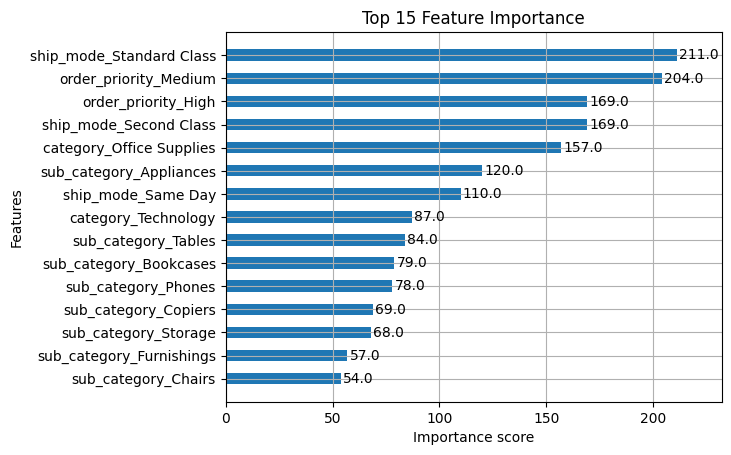

In [245]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15, height=0.5)
plt.title("Top 15 Feature Importance")
plt.show()


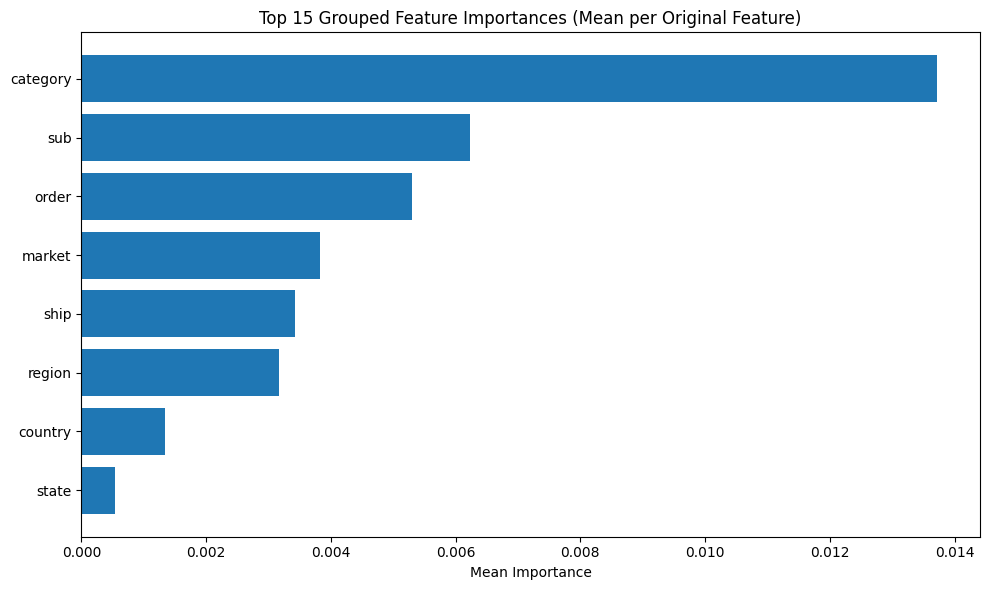

In [246]:
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ambil feature importances dan nama kolom
importances = model.feature_importances_
feature_names = X.columns

# Kelompokkan berdasarkan fitur aslinya
grouped_importances = defaultdict(list)

for feat, imp in zip(feature_names, importances):
    if '_' in feat:
        base_feat = feat.split('_')[0]
    else:
        base_feat = feat  # fitur numerik asli
    grouped_importances[base_feat].append(imp)

# Hitung rata-rata importance per fitur asli
grouped_df = pd.DataFrame({
    'Feature': list(grouped_importances.keys()),
    'Importance': [np.mean(imps) for imps in grouped_importances.values()]
})

# Urutkan dan ambil 15 teratas
grouped_df = grouped_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(grouped_df['Feature'][::-1], grouped_df['Importance'][::-1])
plt.title("Top 15 Grouped Feature Importances (Mean per Original Feature)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()


In [247]:
import shap

In [235]:
X = df_all

In [236]:
import shap

# Buat explainer
explainer = shap.Explainer(model, X)

# Hitung SHAP values
shap_values = explainer(X)

# Summary plot: bar plot mean absolute SHAP values (importance global)
shap.plots.bar(shap_values, max_display=15)


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

In [234]:
X_train

,state_'Amman,state_'Asir,state_Abia,state_Abruzzi,state_Abuja Capital Territory,state_Aceh,state_Acre,state_Ad Dawhah,state_Adamaoua,state_Adamawa,...,sub_category_Storage,sub_category_Supplies,sub_category_Tables,order_priority_High,order_priority_Low,order_priority_Medium,quantity,discount,sales,profit
2558,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,1,0.000000e+00,29,4.360000e+00
15041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,6,4.020000e-01,345,-2.436264e+01
38072,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,2,7.000000e-01,88,-1.605060e+02
15694,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,9,2.000000e-01,717,1.523880e+02
30044,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,3,1.700000e-01,1244,-1.348956e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,1,0.000000e+00,6,3.110400e+00
44732,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,3,0.000000e+00,105,2.830950e+01
38158,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,6,0.000000e+00,1002,8.010000e+01
860,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,2,0.000000e+00,18,3.180000e+00


## Hypertuning

In [187]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from xgboost import XGBRegressor
import numpy as np

# Scorer untuk RMSE (negatif karena sklearn ingin skor "lebih tinggi lebih baik")
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

# Parameter grid untuk dicoba
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 6, 8, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Model dasar
xgb_model = XGBRegressor(random_state=42, n_jobs=-1)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,  # jumlah kombinasi yang dicoba
    scoring=rmse_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit ke data
random_search.fit(X_train, y_train)

# Hasil terbaik
print("Best RMSE (negated):", random_search.best_score_)
print("Best parameters:", random_search.best_params_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RMSE (negated): -48.879606218010885
Best parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


In [190]:
model = xgb.XGBRegressor(
    subsample= 0.9, 
    n_estimators = 200,
    max_depth = 5, 
    learning_rate = 0.05,
    colsample_bytree = 0.9,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [248]:
X_train

,state_'Amman,state_'Asir,state_Abia,state_Abruzzi,state_Abuja Capital Territory,state_Aceh,state_Acre,state_Ad Dawhah,state_Adamaoua,state_Adamawa,...,sub_category_Envelopes,sub_category_Fasteners,sub_category_Furnishings,sub_category_Labels,sub_category_Machines,sub_category_Paper,sub_category_Phones,sub_category_Storage,sub_category_Supplies,sub_category_Tables
2558,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
15041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
38072,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15694,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30044,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
44732,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
38158,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
860,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [191]:
# Evaluasi
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
relative_error = root_mean_squared_error(y_test, y_pred) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')

MAE: 21.365946770195805
RMSE: 49.154564144809314
R² Score: 0.2874401259982564
Relative RMSE: 185.89%


## ALL CAT + NUM

In [114]:
df_all = df[['state','ship_mode', 'segment', 'country', 'market', 'region', 'category', 'sub_category', 'order_priority','quantity','discount','shipping_cost','sales','profit']]


In [115]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# 1. Tentukan target
y = df_all['shipping_cost']

# 2. Pisahkan fitur kategorikal dan numerikal (selain target)
categorical_cols = df_all.drop(columns='shipping_cost').select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df_all.drop(columns='shipping_cost').select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. One-hot encoding untuk fitur kategorikal
X_cat_encoded = pd.get_dummies(df_all[categorical_cols], drop_first=True)

# 4. Gabungkan dengan fitur numerik
X_all = pd.concat([X_cat_encoded, df_all[numerical_cols]], axis=1)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# 5. XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = model.predict(X_test)

# rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(np.sqrt(mean_squared_error(y_test, y_pred)))
relative_error = 25 / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')


R² Score: 0.8085
25.482510022940705
Relative RMSE: 94.54%


In [253]:
relative_error = 24.97 / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')

Relative RMSE: 94.43%


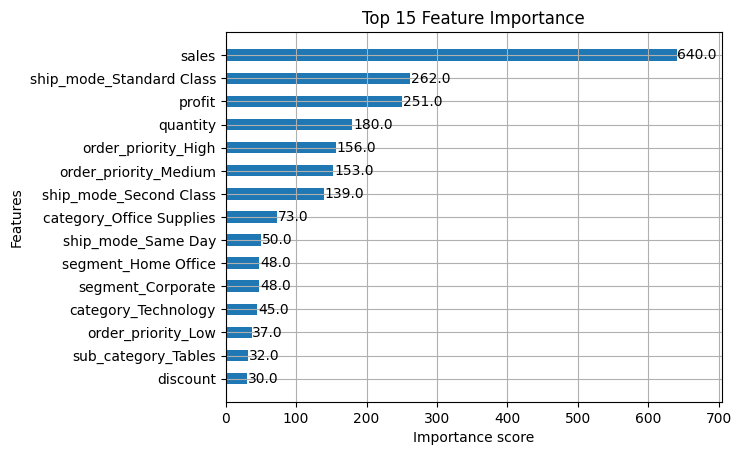

In [119]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15, height=0.5)
plt.title("Top 15 Feature Importance")
plt.show()


## CAT SELECT + NUM

In [249]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from scipy.stats import f_oneway

# 1. Set target ke
y = df_all['shipping_cost']

# 2. Ambil semua fitur kategorikal dan numerikal (kecuali target)
categorical_cols = df_all.drop(columns='shipping_cost').select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df_all.drop(columns='shipping_cost').select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. ANOVA untuk seleksi fitur kategorikal
selected_cols = []
for col in categorical_cols:
    groups = [group['shipping_cost'].dropna() for name, group in df_all.groupby(col)]
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        if p_val < 0.05:
            selected_cols.append(col)

print("Fitur hasil ANOVA:", selected_cols)

# 4. One-hot encoding untuk fitur terpilih
X_cat_encoded = pd.get_dummies(df_all[selected_cols], drop_first=True)

# 5. Gabungkan dengan fitur numerik
X_all = pd.concat([X_cat_encoded, df_all[numerical_cols]], axis=1)

# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)


# 5. XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


Fitur hasil ANOVA: ['state', 'ship_mode', 'country', 'market', 'region', 'category', 'sub_category', 'order_priority']


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [218]:
y_pred = model.predict(X_test)

# rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(np.sqrt(mean_squared_error(y_test, y_pred)))
relative_error = np.sqrt(mean_squared_error(y_test, y_pred)) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')


R² Score: 0.8086
25.47638753356656
Relative RMSE: 96.35%


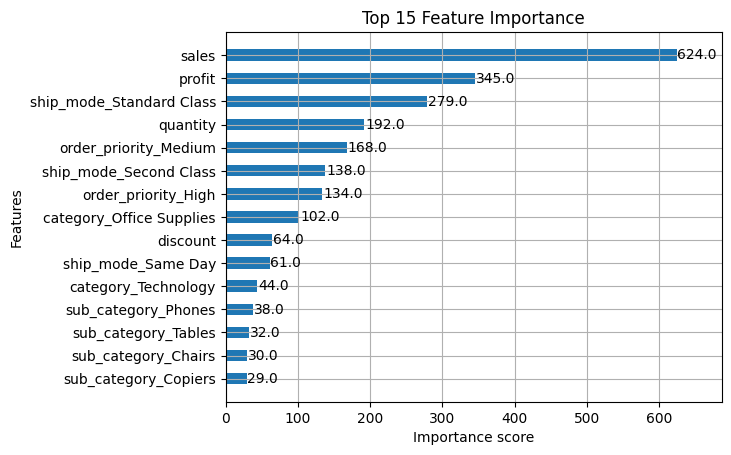

In [219]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15, height=0.5)
plt.title("Top 15 Feature Importance")
plt.show()


In [220]:
categorical_columns = [ 'state','country','ship_mode','order_priority', 'market', 'region', 'category', 'sub_category','shipping_cost']
numerical_columns = ['quantity', 'discount', 'shipping_cost', 'sales', 'profit']

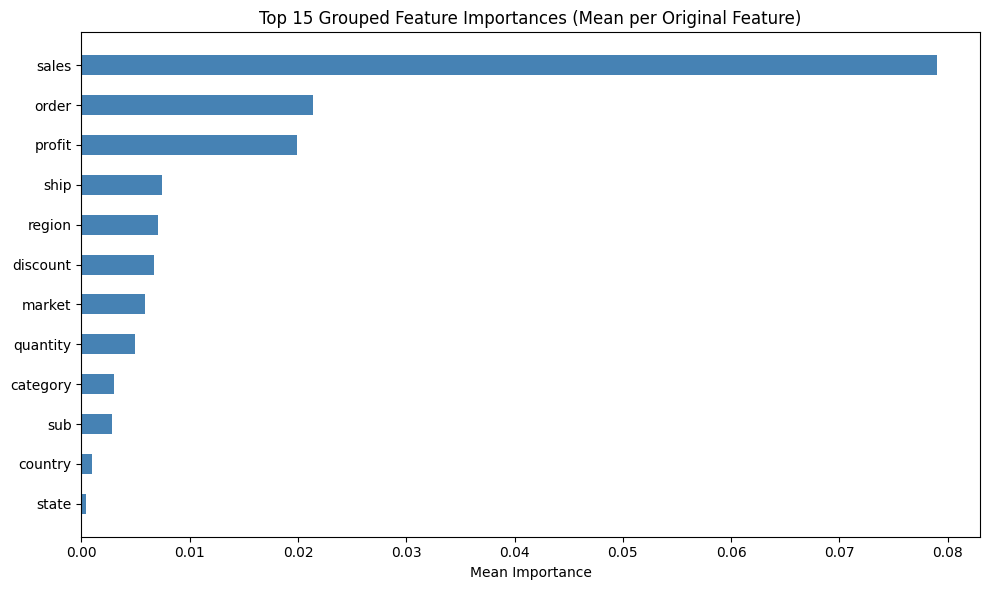

In [221]:
# Ambil feature importances dan nama kolom hasil one-hot encoding
importances = model.feature_importances_
feature_names = X_train.columns

# Kelompokkan berdasarkan nama variabel asli (misalnya 'state_CA' → 'state')
grouped_importances = defaultdict(list)

for feat, imp in zip(feature_names, importances):
    base_feat = feat.split('_')[0]
    grouped_importances[base_feat].append(imp)

# Hitung rata-rata importance per variabel asli
grouped_df = pd.DataFrame({
    'Feature': list(grouped_importances.keys()),
    'Importance': [np.mean(imps) for imps in grouped_importances.values()]
})

# Ambil 15 variabel paling penting
grouped_df = grouped_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(grouped_df['Feature'][::-1], grouped_df['Importance'][::-1], height=0.5, color='steelblue')
plt.title("Top 15 Grouped Feature Importances (Mean per Original Feature)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [208]:
## feature importance

In [210]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from xgboost import XGBRegressor
import numpy as np

# Scorer untuk RMSE (negatif karena sklearn ingin skor "lebih tinggi lebih baik")
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

# Parameter grid untuk dicoba
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 6, 8, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Model dasar
xgb_model = XGBRegressor(random_state=42, n_jobs=-1)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,  # jumlah kombinasi yang dicoba
    scoring=rmse_scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit ke data
random_search.fit(X_train, y_train)

# Hasil terbaik
print("Best RMSE (negated):", random_search.best_score_)
print("Best parameters:", random_search.best_params_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best RMSE (negated): -24.977133388827344
Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [222]:
model = xgb.XGBRegressor(
    subsample= 0.9, 
    n_estimators = 300,
    max_depth = 5, 
    learning_rate = 0.01,
    colsample_bytree = 1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [223]:
# Evaluasi
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
relative_error = root_mean_squared_error(y_test, y_pred) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')

MAE: 8.743912865856187
RMSE: 25.22063554296213
R² Score: 0.8124117136719763
Relative RMSE: 95.38%


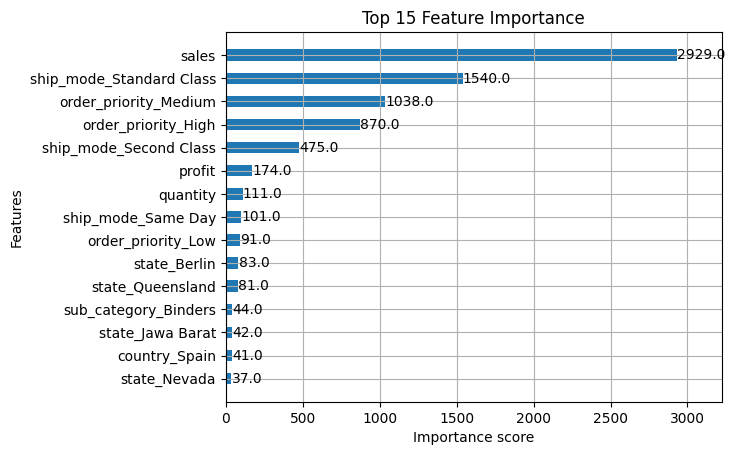

In [224]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15, height=0.5)
plt.title("Top 15 Feature Importance")
plt.show()


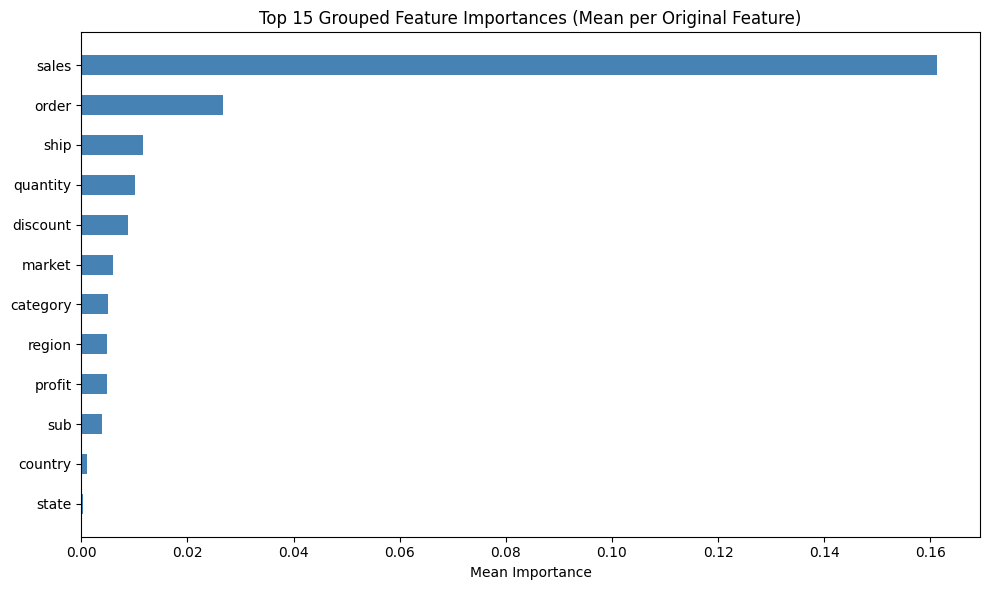

In [225]:
# Ambil feature importances dan nama kolom hasil one-hot encoding
importances = model.feature_importances_
feature_names = X_train.columns

# Kelompokkan berdasarkan nama variabel asli (misalnya 'state_CA' → 'state')
grouped_importances = defaultdict(list)

for feat, imp in zip(feature_names, importances):
    base_feat = feat.split('_')[0]
    grouped_importances[base_feat].append(imp)

# Hitung rata-rata importance per variabel asli
grouped_df = pd.DataFrame({
    'Feature': list(grouped_importances.keys()),
    'Importance': [np.mean(imps) for imps in grouped_importances.values()]
})

# Ambil 15 variabel paling penting
grouped_df = grouped_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(grouped_df['Feature'][::-1], grouped_df['Importance'][::-1], height=0.5, color='steelblue')
plt.title("Top 15 Grouped Feature Importances (Mean per Original Feature)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [232]:
X_train

,state_'Amman,state_'Asir,state_Abia,state_Abruzzi,state_Abuja Capital Territory,state_Aceh,state_Acre,state_Ad Dawhah,state_Adamaoua,state_Adamawa,...,sub_category_Storage,sub_category_Supplies,sub_category_Tables,order_priority_High,order_priority_Low,order_priority_Medium,quantity,discount,sales,profit
2558,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,1,0.000000e+00,29,4.360000e+00
15041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,6,4.020000e-01,345,-2.436264e+01
38072,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,2,7.000000e-01,88,-1.605060e+02
15694,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,9,2.000000e-01,717,1.523880e+02
30044,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,3,1.700000e-01,1244,-1.348956e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,1,0.000000e+00,6,3.110400e+00
44732,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,3,0.000000e+00,105,2.830950e+01
38158,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,6,0.000000e+00,1002,8.010000e+01
860,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,2,0.000000e+00,18,3.180000e+00


In [233]:
X

,state_'Amman,state_'Asir,state_Abia,state_Abruzzi,state_Abuja Capital Territory,state_Aceh,state_Acre,state_Ad Dawhah,state_Adamaoua,state_Adamawa,...,sub_category_Envelopes,sub_category_Fasteners,sub_category_Furnishings,sub_category_Labels,sub_category_Machines,sub_category_Paper,sub_category_Phones,sub_category_Storage,sub_category_Supplies,sub_category_Tables
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51286,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
51287,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
51288,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [251]:
import shap

# Buat explainer
explainer = shap.Explainer(model, X_train)

# Hitung SHAP values
shap_values = explainer(X_train)

# Summary plot: bar plot mean absolute SHAP values (importance global)
shap.plots.bar(shap_values, max_display=15)


TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

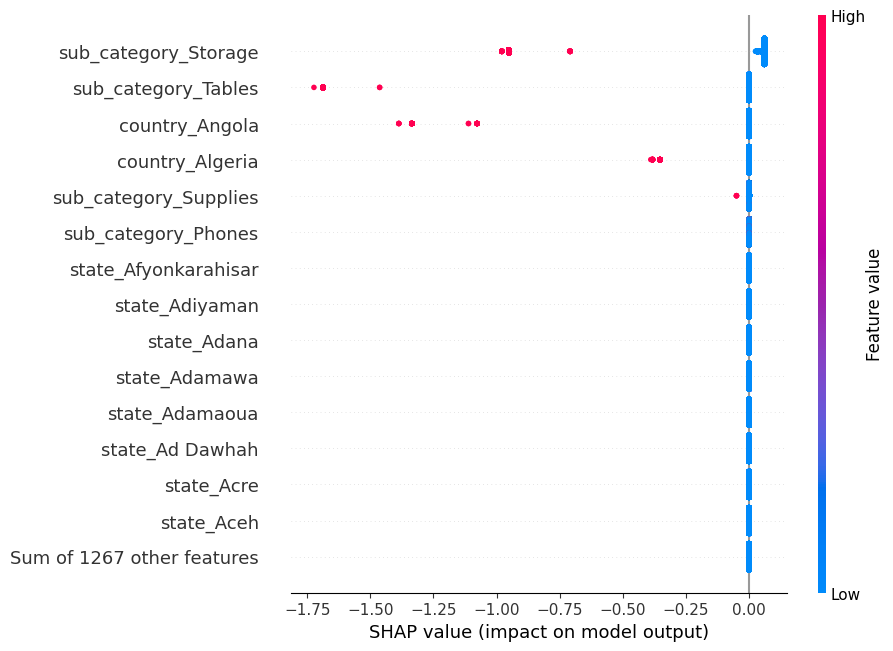

In [231]:
shap.plots.beeswarm(shap_values, max_display=15)


# NON XGB

## Random Forest

In [147]:
# drop kolom non target dan non kategorik
df_ship = df[['state','ship_mode', 'segment', 'country', 'market', 'region', 'category', 'sub_category', 'order_priority','shipping_cost']]
df_ship

,state,ship_mode,segment,country,market,region,category,sub_category,order_priority,shipping_cost
0,Constantine,Standard Class,Consumer,Algeria,Africa,Africa,Office Supplies,Storage,Medium,3.546000e+01
1,New South Wales,Standard Class,Consumer,Australia,APAC,Oceania,Office Supplies,Supplies,Medium,9.720000e+00
2,Budapest,Second Class,Consumer,Hungary,EMEA,EMEA,Office Supplies,Storage,High,8.170000e+00
3,Stockholm,Second Class,Home Office,Sweden,EU,North,Office Supplies,Paper,High,4.820000e+00
4,New South Wales,Standard Class,Consumer,Australia,APAC,Oceania,Furniture,Furnishings,Medium,4.700000e+00
...,...,...,...,...,...,...,...,...,...,...
51285,California,Standard Class,Corporate,United States,US,West,Office Supplies,Binders,Medium,8.900000e-01
51286,Souss-Massa-Draâ,Standard Class,Consumer,Morocco,Africa,Africa,Office Supplies,Binders,Medium,4.900000e-01
51287,Managua,Second Class,Consumer,Nicaragua,LATAM,Central,Office Supplies,Labels,Medium,3.500000e-01
51288,Chihuahua,Standard Class,Consumer,Mexico,LATAM,North,Office Supplies,Labels,Medium,2.000000e-01


In [148]:
df_sel = df_ship[[ 'state','country','ship_mode','order_priority', 'market', 'region', 'category', 'sub_category','shipping_cost']]
df_sel

,state,country,ship_mode,order_priority,market,region,category,sub_category,shipping_cost
0,Constantine,Algeria,Standard Class,Medium,Africa,Africa,Office Supplies,Storage,3.546000e+01
1,New South Wales,Australia,Standard Class,Medium,APAC,Oceania,Office Supplies,Supplies,9.720000e+00
2,Budapest,Hungary,Second Class,High,EMEA,EMEA,Office Supplies,Storage,8.170000e+00
3,Stockholm,Sweden,Second Class,High,EU,North,Office Supplies,Paper,4.820000e+00
4,New South Wales,Australia,Standard Class,Medium,APAC,Oceania,Furniture,Furnishings,4.700000e+00
...,...,...,...,...,...,...,...,...,...
51285,California,United States,Standard Class,Medium,US,West,Office Supplies,Binders,8.900000e-01
51286,Souss-Massa-Draâ,Morocco,Standard Class,Medium,Africa,Africa,Office Supplies,Binders,4.900000e-01
51287,Managua,Nicaragua,Second Class,Medium,LATAM,Central,Office Supplies,Labels,3.500000e-01
51288,Chihuahua,Mexico,Standard Class,Medium,LATAM,North,Office Supplies,Labels,2.000000e-01


In [160]:
# Pastikan target (sales) tidak di-encode
categorical_cols = df_sel.drop(columns='shipping_cost').select_dtypes(include=['object', 'category']).columns.tolist()

# Lakukan One-Hot Encoding
df_encoded_all = pd.get_dummies(df_sel, columns=categorical_cols, drop_first=True)

# Tampilkan bentuk akhir dataframe
print(f"Shape awal: {df_sel.shape}")
print(f"Shape setelah One-Hot Encoding: {df_encoded_all.shape}")


Shape awal: (51290, 9)
Shape setelah One-Hot Encoding: (51290, 1282)


In [161]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Pisahkan target dan fitur
X = df_encoded_all.drop(columns='shipping_cost')
y = df_encoded_all['shipping_cost']


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# X = pd.concat([X_cat_encoded, df[numerical_cols]], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)




MAE: 22.131392352530117


TypeError: got an unexpected keyword argument 'squared'

In [130]:
# Evaluasi
y_pred = rf_model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 22.131392352530117
RMSE: 54.430433875846084
R² Score: 0.1262699837820862


In [134]:
y_test.mean()

np.float64(26.442658412945995)

In [133]:
relative_error = root_mean_squared_error(y_test, y_pred) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')

Relative RMSE: 205.84%


## Linear Regression

In [162]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediksi
y_pred_lr = lr_model.predict(X_test)

In [163]:

# Evaluasi
print("=== Linear Regression ===")
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", root_mean_squared_error(y_test, y_pred_lr))
print("R²  :", r2_score(y_test, y_pred_lr))
relative_error = root_mean_squared_error(y_test, y_pred_lr) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')


=== Linear Regression ===
MAE : 71.11061573468847
RMSE: 172.9118071264356
R²  : 0.08891408041960547
Relative RMSE: 542.80%


## Boosting

In [164]:
from sklearn.ensemble import GradientBoostingRegressor

# Model
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

# Prediksi
y_pred_gbr = gbr_model.predict(X_test)


In [165]:
# Evaluasi
print("=== Gradient Boosting Regressor ===")
print("MAE :", mean_absolute_error(y_test, y_pred_gbr))
print("RMSE:", root_mean_squared_error(y_test, y_pred_gbr))
print("R²  :", r2_score(y_test, y_pred_gbr))
relative_error = root_mean_squared_error(y_test, y_pred_gbr) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')

=== Gradient Boosting Regressor ===
MAE : 60.718512415282845
RMSE: 171.52954476252052
R²  : 0.10342235625295737
Relative RMSE: 538.46%


## XGB

In [168]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBRegressor()

model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [169]:
y_pred = model.predict(X_test)

In [170]:
# Evaluasi
print("=== XGBoost ===")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))
relative_error = root_mean_squared_error(y_test, y_pred) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')

=== XGBoost ===
MAE : 21.53964180220297
RMSE: 49.63965491428933
R²  : 0.27330667534948305
Relative RMSE: 187.73%


## SVR

In [171]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Pipeline: scaling + SVR
svr_pipeline = make_pipeline(StandardScaler(), SVR())

# Fit
svr_pipeline.fit(X_train, y_train)

# Prediksi
y_pred_svr = svr_pipeline.predict(X_test)


In [172]:
# Evaluasi
print("=== Support Vector Regressor ===")
print("MAE :", mean_absolute_error(y_test, y_pred_svr))
print("RMSE:", root_mean_squared_error(y_test, y_pred_svr))
print("R²  :", r2_score(y_test, y_pred_svr))
relative_error = root_mean_squared_error(y_test, y_pred_svr) / y_test.mean()
print(f'Relative RMSE: {relative_error:.2%}')


=== Support Vector Regressor ===
MAE : 20.622046291148393
RMSE: 57.43409297376418
R²  : 0.027178417277137767
Relative RMSE: 217.20%
